# 01. Data Exploration (EDA)
Dataset yang digunakan adalah data sintetis berbasis data historis ride-hailing 
Boston (cab_rides.csv + weather.csv) yang diaugmentasi dengan logika pasca-konser 
GBK Jakarta. Notebook ini mendokumentasikan distribusi data sebelum training.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/features.csv")
print(f"Shape: {df.shape}")
print(f"\nTipe data:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (101836, 7)

Tipe data:
concert_end_hour               int64
day_type                      object
concert_size                  object
weather                       object
time_since_end_minutes         int64
distance_to_pickup_meters      int64
surge_multiplier             float64
dtype: object

Missing values:
concert_end_hour             0
day_type                     0
concert_size                 0
weather                      0
time_since_end_minutes       0
distance_to_pickup_meters    0
surge_multiplier             0
dtype: int64


,concert_end_hour,day_type,concert_size,weather,time_since_end_minutes,distance_to_pickup_meters,surge_multiplier
0,21,weekday,small,cloudy,22,380,1.40
1,24,weekday,large,cloudy,84,380,1.36
2,22,weekend,medium,cloudy,24,650,2.39
3,22,weekday,small,cloudy,74,650,1.09
4,21,weekend,medium,cloudy,15,120,3.09


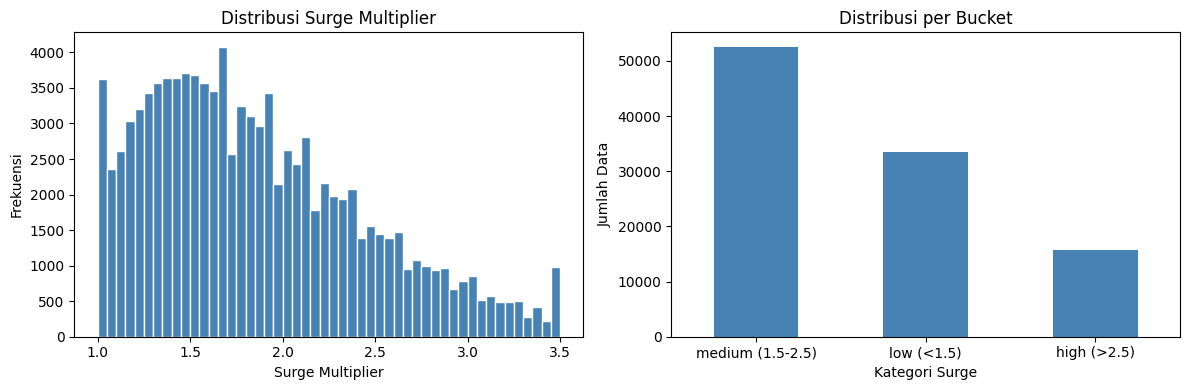

count    101836.000000
mean          1.860613
std           0.588826
min           1.000000
25%           1.390000
50%           1.760000
75%           2.230000
max           3.500000
Name: surge_multiplier, dtype: float64


In [3]:
# Distribusi surge_multiplier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["surge_multiplier"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribusi Surge Multiplier")
axes[0].set_xlabel("Surge Multiplier")
axes[0].set_ylabel("Frekuensi")

# Bucket distribution
buckets = pd.cut(df["surge_multiplier"],
                 bins=[0, 1.5, 2.5, 3.5],
                 labels=["low (<1.5)", "medium (1.5-2.5)", "high (>2.5)"])
buckets.value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Distribusi per Bucket")
axes[1].set_xlabel("Kategori Surge")
axes[1].set_ylabel("Jumlah Data")
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig("../models/eda_surge_distribution.png", dpi=150)
plt.show()
print(df["surge_multiplier"].describe())

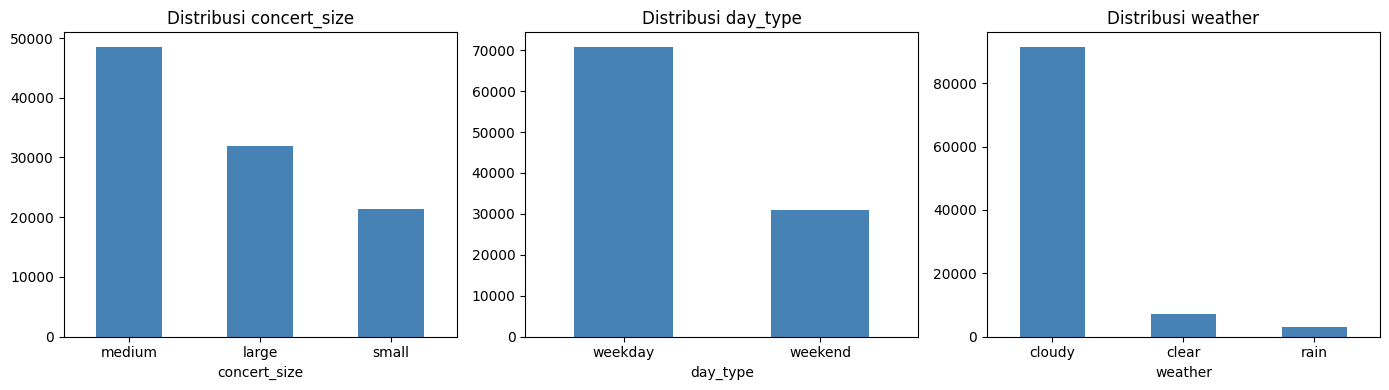

In [4]:
# Distribusi fitur kategorikal
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["concert_size", "day_type", "weather"]):
    df[col].value_counts().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Distribusi {col}")
    ax.tick_params(rotation=0)

plt.tight_layout()
plt.savefig("../models/eda_categorical.png", dpi=150)
plt.show()

In [5]:
# Surge rata-rata per kombinasi fitur
print("Surge mean per concert_size:")
print(df.groupby("concert_size")["surge_multiplier"].mean().round(3))

print("\nSurge mean per day_type:")
print(df.groupby("day_type")["surge_multiplier"].mean().round(3))

print("\nSurge mean per weather:")
print(df.groupby("weather")["surge_multiplier"].mean().round(3))

print("\nSurge mean per concert_end_hour:")
print(df.groupby("concert_end_hour")["surge_multiplier"].mean().round(3))

Surge mean per concert_size:
concert_size
large     2.122
medium    1.867
small     1.456
Name: surge_multiplier, dtype: float64

Surge mean per day_type:
day_type
weekday    1.742
weekend    2.133
Name: surge_multiplier, dtype: float64

Surge mean per weather:
weather
clear     1.577
cloudy    1.880
rain      1.962
Name: surge_multiplier, dtype: float64

Surge mean per concert_end_hour:
concert_end_hour
19    1.561
20    1.669
21    1.789
22    1.896
23    2.002
24    2.102
Name: surge_multiplier, dtype: float64


## Temuan EDA
- Dataset tidak memiliki missing values
- Distribusi surge condong ke kiri (mayoritas low-medium surge) — realistis
- concert_size dan time_since_end_minutes adalah driver utama surge
- weekend secara konsisten menghasilkan surge lebih tinggi dari weekday
- Jam larut malam (22-24) menunjukkan surge yang lebih tinggi